In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold,
    KFold
)
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import joblib

In [2]:
df=pd.read_csv("/content/student_dropout_data.csv")

In [3]:
df

,Unnamed: 0,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,Single,2nd phase-general contingent,5,Animation and Multimedia Design,daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,Single,International student(bachelor),1,Tourism,daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,2,Single,1st phase-general contingent,5,Communication Design,daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,3,Single,2nd phase-general contingent,2,Journalism and Communication,daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,4,Married,Over 23 years old,1,Social service(evening),evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,4419,Single,1st phase-general contingent,6,Journalism and Communication,daytime,Secondary education,125.0,Portuguese,Secondary Education - 12th Year of Schooling o...,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,4420,Single,1st phase-general contingent,2,Journalism and Communication,daytime,Secondary education,120.0,Russian,Secondary Education - 12th Year of Schooling o...,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,4421,Single,1st phase-general contingent,1,Nrsing,daytime,Secondary education,154.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,4422,Single,1st phase-general contingent,1,Management,daytime,Secondary education,180.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Unnamed: 0                                      4424 non-null   int64  
 1   Marital status                                  4424 non-null   object 
 2   Application mode                                4424 non-null   object 
 3   Application order                               4424 non-null   int64  
 4   Course                                          4424 non-null   object 
 5   Daytime/evening attendance	                     4424 non-null   object 
 6   Previous qualification                          4424 non-null   object 
 7   Previous qualification (grade)                  4424 non-null   float64
 8   Nacionality                                     4424 non-null   object 
 9   Mother's qualification                   

In [5]:
df=df[df["Target"]!="Enrolled"]

In [6]:
df.head(5)

,Unnamed: 0,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,Single,2nd phase-general contingent,5,Animation and Multimedia Design,daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,Single,International student(bachelor),1,Tourism,daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,2,Single,1st phase-general contingent,5,Communication Design,daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,3,Single,2nd phase-general contingent,2,Journalism and Communication,daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,4,Married,Over 23 years old,1,Social service(evening),evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [7]:
label_encoder={}
for col in df.select_dtypes(include=["object"]).columns:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col].astype(str))
    label_encoder[col]=le




In [8]:
df.head()

,Unnamed: 0,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,4,3,5,2,0,15,122.0,13,9,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,4,9,1,15,0,15,160.0,13,24,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,2,4,0,5,5,0,15,122.0,13,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,3,4,3,2,8,0,15,122.0,13,8,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,4,3,14,1,14,1,15,100.0,13,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1


<Axes: >

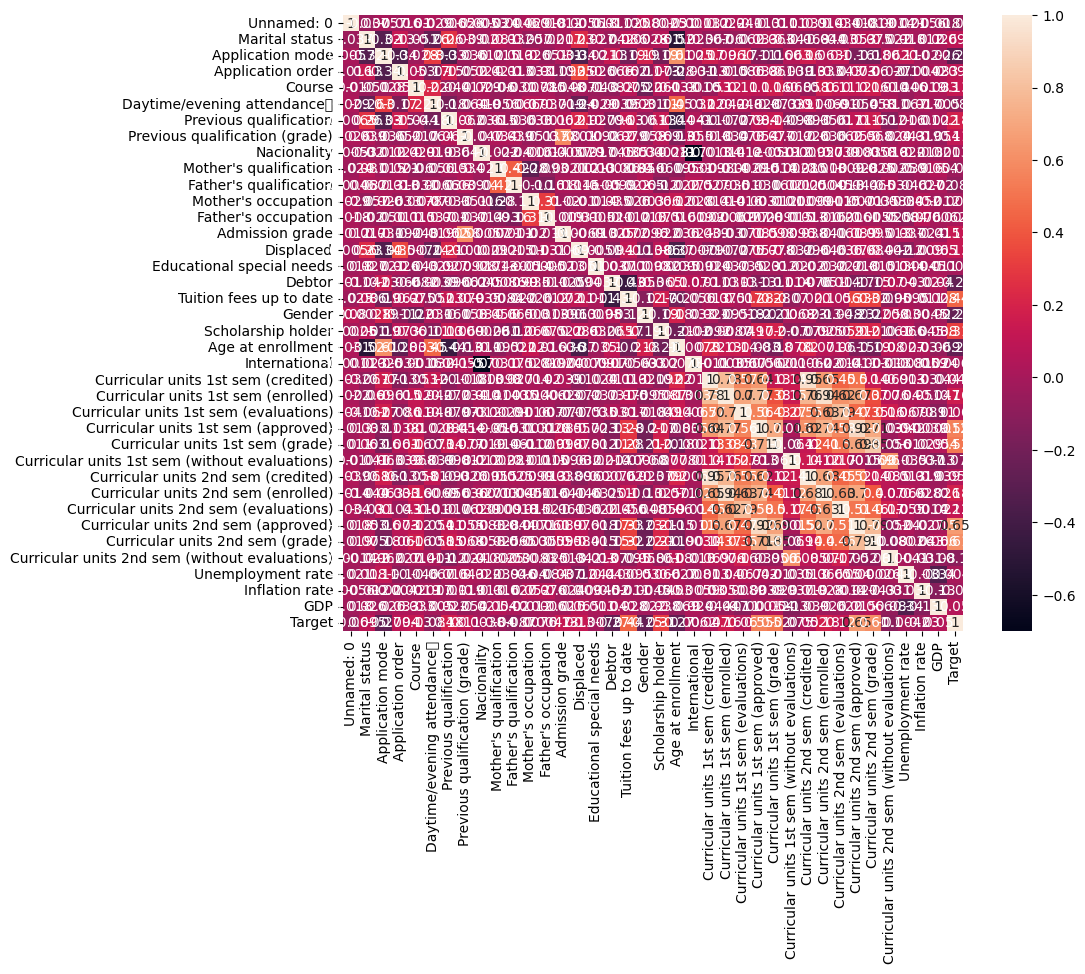

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)


In [10]:
X=df.drop(columns=["Target","Unnamed: 0"])
y=df["Target"]

In [33]:
X.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [11]:
y.value_counts()

,count
Target,
1,2209
0,1421


In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [14]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [15]:
# Logistic Regression
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Hyperparameters
lr_params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# GridSearchCV
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=cv,
    scoring="f1",
    error_score="raise"
)

# Fit
lr_grid.fit(X_train_scaled, y_train)

# Best model
best_lr = lr_grid.best_estimator_

print("Best Parameters:", lr_grid.best_params_)
print("Best CV Score:", lr_grid.best_score_)

Best Parameters: {'C': 0.1}
Best CV Score: 0.9255186482670397


In [16]:
svm = SVC(random_state=42)
svm_params = {
    "C": [0.001,0.01,0.1, 1, 10,100],
    "kernel": ["rbf","poly"],
    "gamma": ["scale","auto"]
}
svm_stratified = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    cv=cv,
    scoring="f1",
    n_jobs=1,
    verbose=2
)
svm_stratified.fit(X_train_scaled, y_train)

best_svm = svm_stratified.best_estimator_

print("StratifiedKFold Best Parameters:", svm_stratified.best_params_)
print("StratifiedKFold Best CV Score:", svm_stratified.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ...................C=0.001, gamma=scale, kernel=rbf; total time=   0.8s
[CV] END ...................C=0.001, gamma=scale, kernel=rbf; total time=   0.6s
[CV] END ...................C=0.001, gamma=scale, kernel=rbf; total time=   0.5s
[CV] END ...................C=0.001, gamma=scale, kernel=rbf; total time=   0.8s
[CV] END ...................C=0.001, gamma=scale, kernel=rbf; total time=   1.0s
[CV] END ..................C=0.001, gamma=scale, kernel=poly; total time=   0.6s
[CV] END ..................C=0.001, gamma=scale, kernel=poly; total time=   0.8s
[CV] END ..................C=0.001, gamma=scale, kernel=poly; total time=   1.2s
[CV] END ..................C=0.001, gamma=scale, kernel=poly; total time=   1.2s
[CV] END ..................C=0.001, gamma=scale, kernel=poly; total time=   0.8s
[CV] END ....................C=0.001, gamma=auto, kernel=rbf; total time=   1.0s
[CV] END ....................C=0.001, gamma=aut

In [17]:
knn = KNeighborsClassifier()
knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}
knn_stratified = GridSearchCV(
    estimator=knn,
    param_grid=knn_params,
    cv=cv,
    scoring="f1",
    error_score="raise"
)
knn_stratified.fit(X_train_scaled, y_train)
best_knn = knn_stratified.best_estimator_

print("StratifiedKFold Best Parameters:", knn_stratified.best_params_)
print("StratifiedKFold Best CV Score:", knn_stratified.best_score_)

StratifiedKFold Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
StratifiedKFold Best CV Score: 0.8974217353551278


In [18]:
nb = GaussianNB()
nb_params = {
    "var_smoothing":np.logspace(0,-9,20)
}
nb_stratified = GridSearchCV(
    estimator=nb,
    param_grid=nb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
nb_stratified.fit(X_train_scaled, y_train)
best_nb = nb_stratified.best_estimator_

print("StratifiedKFold Best Parameters:", nb_stratified.best_params_)
print("StratifiedKFold Best CV Score:", nb_stratified.best_score_)

StratifiedKFold Best Parameters: {'var_smoothing': np.float64(0.3359818286283782)}
StratifiedKFold Best CV Score: 0.8764459256975667


In [34]:
rf=RandomForestClassifier(random_state=42)
rf_params={
    "n_estimators":[100,200,300,400,500],
    "max_depth":[10,20,None,30,40],
    "min_samples_split":[2,5,7],
    "min_samples_leaf":[1,2]
}
rf_stratified=GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)
rf_stratified.fit(X_train_scaled,y_train)
best_rf=rf_stratified.best_estimator_
print("StratifiedKFold Best Parameters:",rf_stratified.best_params_)
print("StratifiedKFold Best CV Score:",rf_stratified.best_score_)

StratifiedKFold Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
StratifiedKFold Best CV Score: 0.9268369164078599


In [35]:
xgb=XGBClassifier(random_state=42,objective="binary:logistic",eval_metric="logloss")
xgb_params={
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1],
    "subsample":[0.8,1],
    "colsample_bytree":[0.8,1]
}
xgb_stratified=GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)
xgb_stratified.fit(X_train_scaled,y_train)
best_xgb=xgb_stratified.best_estimator_
print("StratifiedKFold Best Parameters:",xgb_stratified.best_params_)
print("StratifiedKFold Best CV Score:",xgb_stratified.best_score_)

StratifiedKFold Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
StratifiedKFold Best CV Score: 0.9311508395875465


In [36]:
models_cv={
    "Logistic Regression":(best_lr,X_train_scaled),
    "Support Vector Machine":(best_svm,X_train_scaled),
    "K-Nearest Neighbors":(best_knn,X_train_scaled),
    "Naive Bayes":(best_nb,X_train_scaled),
    "Random Forest":(best_rf,X_train_scaled),
    "XGBoost":(best_xgb,X_train_scaled)
}
for name,(model,data) in models_cv.items():
    score=cross_val_score(model,data,y_train,cv=cv,scoring="f1")
    print(f"{name} CV Score:{score.mean()}")


Logistic Regression CV Score:0.9255186482670397
Support Vector Machine CV Score:0.9234115934752951
K-Nearest Neighbors CV Score:0.8974217353551278
Naive Bayes CV Score:0.8764459256975667
Random Forest CV Score:0.9268369164078599
XGBoost CV Score:0.9311508395875465


In [37]:
def evaluate_model(model, X_test_scaled, y_test):
  y_pred = model.predict(X_test_scaled)
  if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test_scaled)[:,1]
  else:
    y_prob = model.decision_function(X_test_scaled)
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_prob)
  print("="*60)
  print(type(model).__name__)
  print("="*60)
  print(f"Accuracy : {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall : {recall:.4f}")
  print(f"F1 Score : {f1:.4f}")
  print(f"ROC AUC : {roc_auc:.4f}")
  print("\nClassification Report\n")
  print(classification_report(y_test, y_pred))
  ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
  plt.title(type(model).__name__)
  plt.show()
  RocCurveDisplay.from_predictions(y_test, y_prob)
  plt.title(type(model).__name__)
  plt.show()
  return accuracy, precision, recall, f1, roc_auc

LogisticRegression
Accuracy : 0.9174
Precision: 0.9064
Recall : 0.9638
F1 Score : 0.9342
ROC AUC : 0.9533

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.85      0.89       284
           1       0.91      0.96      0.93       442

    accuracy                           0.92       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.92      0.92       726



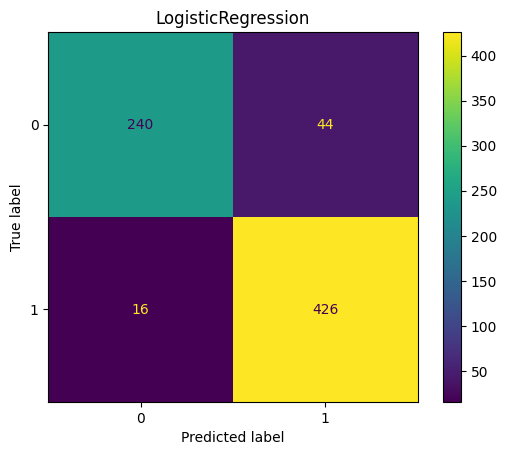

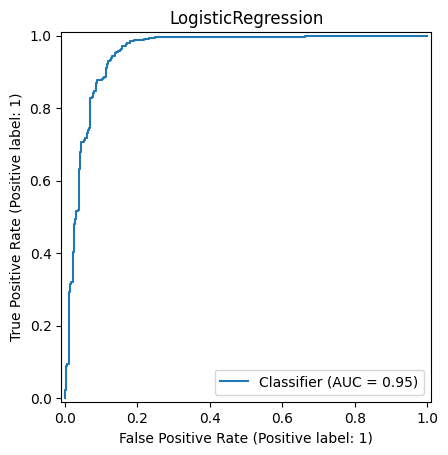

SVC
Accuracy : 0.9105
Precision: 0.8871
Recall : 0.9774
F1 Score : 0.9300
ROC AUC : 0.9515

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.81      0.88       284
           1       0.89      0.98      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



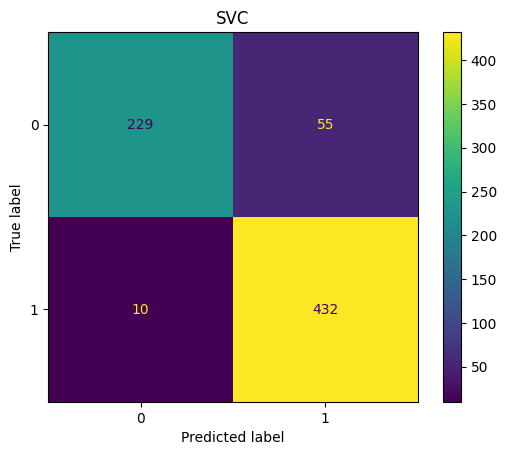

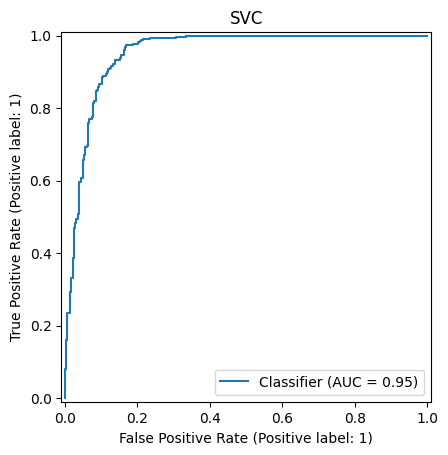

KNeighborsClassifier
Accuracy : 0.8512
Precision: 0.8139
Recall : 0.9796
F1 Score : 0.8891
ROC AUC : 0.9240

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.65      0.77       284
           1       0.81      0.98      0.89       442

    accuracy                           0.85       726
   macro avg       0.88      0.82      0.83       726
weighted avg       0.87      0.85      0.84       726



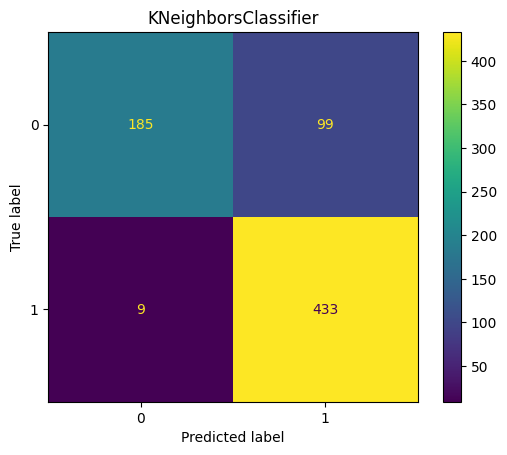

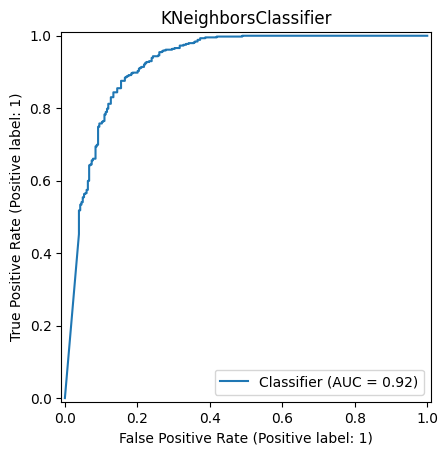

GaussianNB
Accuracy : 0.8333
Precision: 0.8269
Recall : 0.9186
F1 Score : 0.8703
ROC AUC : 0.8989

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.70      0.77       284
           1       0.83      0.92      0.87       442

    accuracy                           0.83       726
   macro avg       0.84      0.81      0.82       726
weighted avg       0.83      0.83      0.83       726



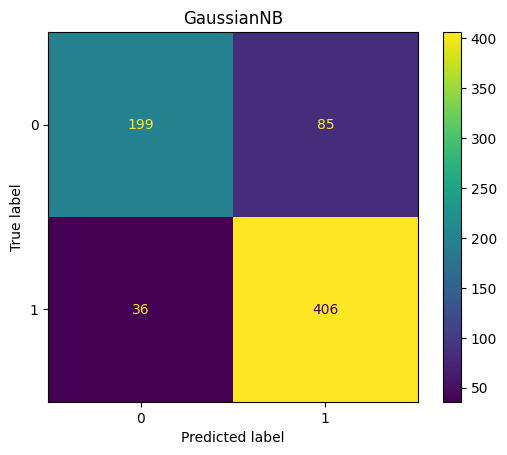

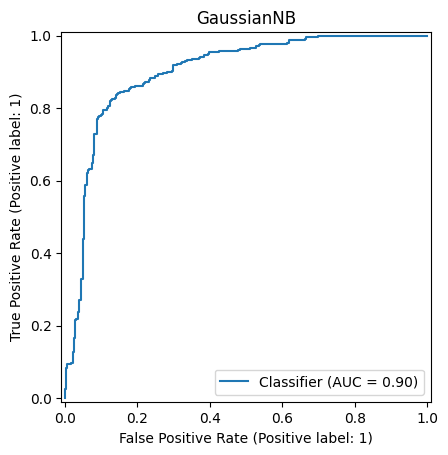

RandomForestClassifier
Accuracy : 0.9146
Precision: 0.8926
Recall : 0.9774
F1 Score : 0.9330
ROC AUC : 0.9535

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.82      0.88       284
           1       0.89      0.98      0.93       442

    accuracy                           0.91       726
   macro avg       0.93      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726



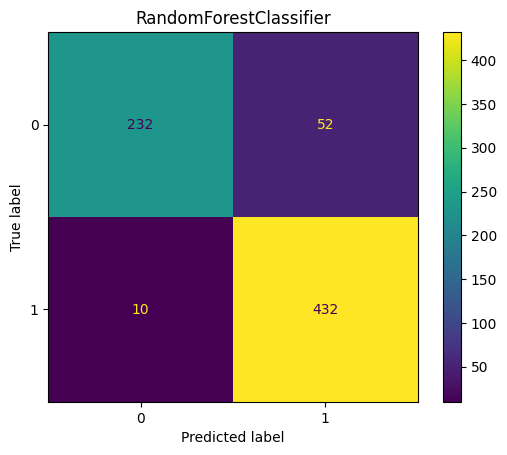

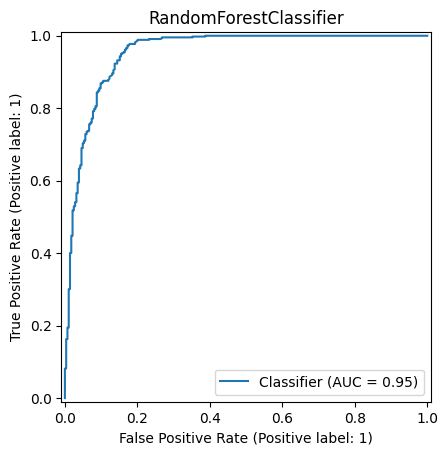

XGBClassifier
Accuracy : 0.9063
Precision: 0.8896
Recall : 0.9661
F1 Score : 0.9262
ROC AUC : 0.9566

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.81      0.87       284
           1       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.90       726



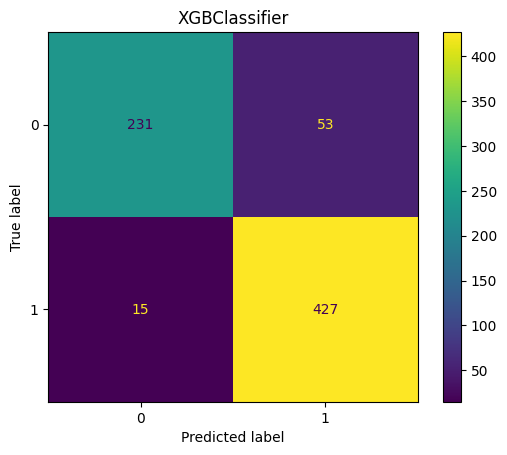

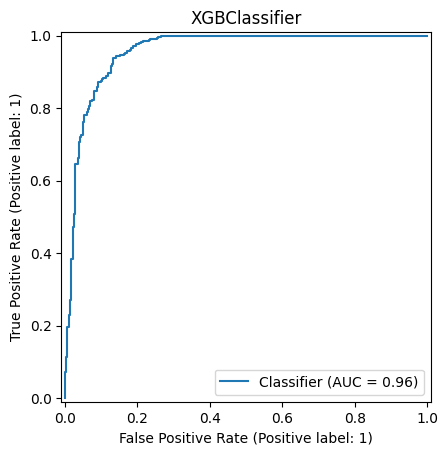

In [38]:
results = []
models = {
  "Logistic Regression": (best_lr, X_test_scaled),
  "SVM": (best_svm, X_test_scaled),
  "KNN": (best_knn, X_test_scaled),
  "Naive Bayes": (best_nb, X_test_scaled),
  "Random Forest": (best_rf, X_test_scaled),
  "XGBoost": (best_xgb, X_test_scaled)
}
for name, (model, X_eval) in models.items():
  accuracy, precision, recall, f1, roc_auc = evaluate_model(
    model,
    X_eval,
    y_test
  )
  results.append([
    name,
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
  ])


In [39]:
comparison=pd.DataFrame(results,
                        columns=["Model","Accuracy","Precision","Recall","F1 Score","Roc-auc"])
comparison=comparison.sort_values(by="F1 Score",ascending=False)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,Roc-auc
0,Logistic Regression,0.917355,0.906383,0.963801,0.934211,0.953325
4,Random Forest,0.914601,0.892562,0.977376,0.933045,0.953504
1,SVM,0.910468,0.887064,0.977376,0.930032,0.951525
5,XGBoost,0.906336,0.889583,0.966063,0.926247,0.956639
2,KNN,0.851240,0.813910,0.979638,0.889117,0.923993
3,Naive Bayes,0.833333,0.826884,0.918552,0.870311,0.898891


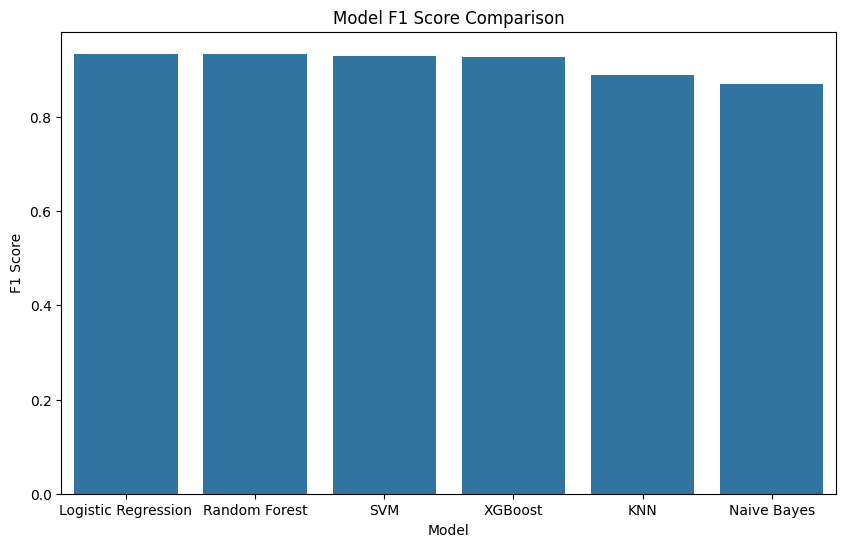

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(data=comparison,x="Model",y="F1 Score")
plt.title("Model F1 Score Comparison")
plt.show()

In [41]:
voting=VotingClassifier(estimators=[
    ('lr',LogisticRegression(C=10, max_iter=1000, random_state=42,solver="liblinear")),
    ('svm',SVC(C=10, random_state=42,probability=True)),
    ('knn',KNeighborsClassifier(metric='manhattan', n_neighbors=15, weights='distance')),
    ('nb',GaussianNB(var_smoothing=np.float64(1.0)))], voting='soft')
voting.fit(X_train_scaled,y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=10, max_iter=1000,
                                                 random_state=42,
                                                 solver='liblinear')),
                             ('svm',
                              SVC(C=10, probability=True, random_state=42)),
                             ('knn',
                              KNeighborsClassifier(metric='manhattan',
                                                   n_neighbors=15,
                                                   weights='distance')),
                             ('nb', GaussianNB(var_smoothing=np.float64(1.0)))],
                 voting='soft')

VotingClassifier
Accuracy : 0.9063
Precision: 0.8785
Recall : 0.9819
F1 Score : 0.9274
ROC AUC : 0.9504

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.79      0.87       284
           1       0.88      0.98      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.90       726



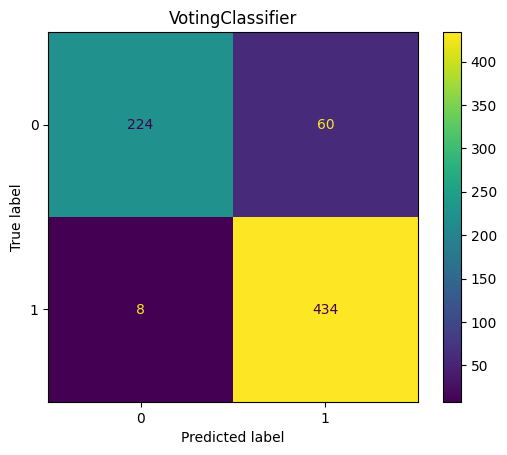

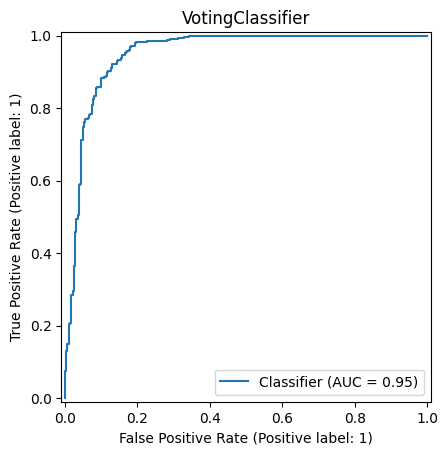

(0.90633608815427,
 0.8785425101214575,
 0.9819004524886877,
 0.9273504273504274,
 np.float64(0.9503935376967689))

In [42]:
evaluate_model(voting,X_test_scaled,y_test)

In [43]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_
})
importance=importance.sort_values(by="Importance",ascending=False)

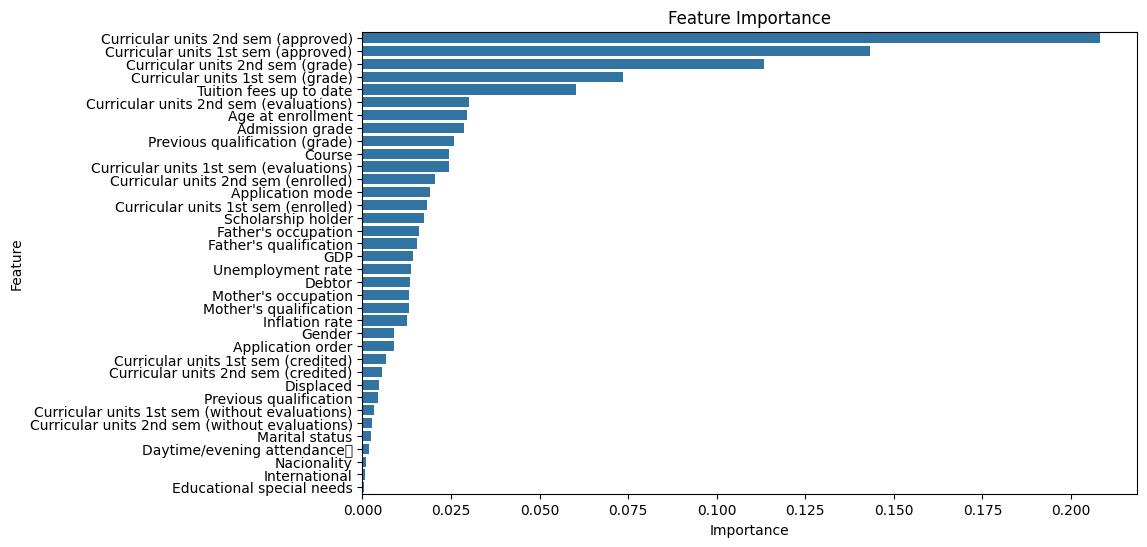

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance,y="Feature",x="Importance")
plt.title("Feature Importance")
plt.show()

In [45]:
best_model={
    "Logistice Regression":best_lr,
    "Support Vector Machine":best_svm,
    "K-Nearest Neighbors":best_knn,
    "Naive Bayes":best_nb,
    "Random Forest":best_rf,
    "XGBoost":best_xgb,
    "Voting Classifier":voting
}
for name,model in best_model.items():
  joblib.dump(model,f"{name}.pkl")

In [46]:
joblib.dump(label_encoder,"label_encoder.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']